# Multi-Agent Path Finding (MAPF) con PuLP

En este problema tenemos varios robots que deben desplazarse desde un nodo
de origen hasta un nodo destino dentro de una red o rejilla.

El objetivo es encontrar rutas para todos los robots evitando:

- Que dos robots ocupen el mismo nodo al mismo tiempo.
- Que dos robots intercambien posiciones atravesando la misma arista
  en sentidos opuestos.
- Que un robot se quede sin continuidad en su recorrido.

El problema se formula como un modelo de Programación Lineal Entera Mixta
(MILP) y se resuelve utilizando PuLP.

Instalar PuLP

In [1]:
!pip install pulp -q

Importar librerías

In [2]:
import pulp
import matplotlib.pyplot as plt
import networkx as nx

## 1. Construcción de la red

Representamos el espacio donde se desplazan los robots mediante un grafo.

Cada celda de la rejilla corresponde a un nodo y dos nodos son vecinos
cuando un robot puede desplazarse directamente entre ellos.

Además de los movimientos hacia arriba, abajo, izquierda y derecha,
permitimos que un robot permanezca en el mismo nodo mediante un arco
de espera `(v,v)`.

In [3]:
# Dimensiones de la rejilla
FILAS = 5
COLUMNAS = 5

# Conjunto de nodos
V = [(i, j) for i in range(FILAS) for j in range(COLUMNAS)]

# Aristas dirigidas
E = []

for i, j in V:
    # Esperar en el mismo nodo
    E.append(((i, j), (i, j)))

    # Arriba
    if i > 0:
        E.append(((i, j), (i-1, j)))

    # Abajo
    if i < FILAS - 1:
        E.append(((i, j), (i+1, j)))

    # Izquierda
    if j > 0:
        E.append(((i, j), (i, j-1)))

    # Derecha
    if j < COLUMNAS - 1:
        E.append(((i, j), (i, j+1)))

print("Número de nodos:", len(V))
print("Número de aristas dirigidas:", len(E))

Número de nodos: 25
Número de aristas dirigidas: 105


## 2. Robots

Cada robot tiene:

- Un nodo de origen.
- Un nodo destino.

El modelo debe encontrar una ruta para cada robot.

Por ejemplo, el robot 0 comienza en `(0,0)` y debe llegar a `(4,4)`.

In [4]:
robots = {
    0: {
        "start": (0, 0),
        "goal": (4, 4)
    },
    1: {
        "start": (0, 4),
        "goal": (4, 0)
    },
    2: {
        "start": (4, 0),
        "goal": (0, 4)
    },
    3: {
        "start": (4, 4),
        "goal": (0, 0)
    }
}

R = list(robots.keys())

print("Robots:", R)

for r in R:
    print(
        f"Robot {r}: "
        f"{robots[r]['start']} -> {robots[r]['goal']}"
    )

Robots: [0, 1, 2, 3]
Robot 0: (0, 0) -> (4, 4)
Robot 1: (0, 4) -> (4, 0)
Robot 2: (4, 0) -> (0, 4)
Robot 3: (4, 4) -> (0, 0)


## 3. Horizonte temporal

Definimos un horizonte máximo `T`.

Esto significa que permitimos que los robots se muevan durante
como máximo `T` instantes.

Si el modelo encuentra una solución antes de `T`, los robots pueden
utilizar movimientos de espera para permanecer en sus posiciones.

In [5]:
T = 20

# Instantes de movimiento
K = range(1, T + 1)

print("Horizonte temporal:", T)

Horizonte temporal: 20


## 4. Variable de decisión

Definimos:

$$
\rho^i_{a,b,k} \in \{0,1\}
$$

donde:

- $i$ = robot.
- $a$ = nodo de origen del movimiento.
- $b$ = nodo destino del movimiento.
- $k$ = instante de tiempo.

La variable vale 1 si el robot $i$ utiliza la arista $(a,b)$
en el instante $k$.

Por ejemplo:

$$
\rho^2_{(1,2),(1,3),5}=1
$$

significa que el robot 2 se mueve desde `(1,2)` hasta `(1,3)`
en el instante 5.

In [6]:
rho = pulp.LpVariable.dicts(
    "rho",
    (
        R,
        range(len(E)),
        K
    ),
    cat=pulp.LpBinary
)

## 5. Variable de tiempo máximo

Definimos una variable:

$$
\beta \geq 0
$$

que representa el instante máximo en el que los robots llegan a
sus respectivos destinos.

El objetivo es:

$$
\min \beta
$$

Por tanto, el modelo intenta encontrar rutas que permitan que todos
los robots lleguen a sus destinos lo más rápido posible.

Para cada robot:

$$
\sum_{k\in T} k\rho^i_{j,t_i,k}\leq\beta
$$

donde $t_i$ es el destino del robot $i$.

In [7]:
beta = pulp.LpVariable(
    "Beta",
    lowBound=0,
    cat=pulp.LpContinuous
)

# Modelo
modelo = pulp.LpProblem(
    "MAPF",
    pulp.LpMinimize
)

# Función objetivo
modelo += beta

## 6. Restricción de origen

La primera restricción de los apuntes es:

$$
\sum_{k=1}^{T}
\sum_{b:(s_i,b)\in E}
\rho^i_{s_i,b,k}
=1
\qquad \forall i\in R
$$

Esta restricción garantiza que cada robot debe salir de su nodo
de origen exactamente una vez.

En otras palabras:

> Cada robot tiene que comenzar su recorrido desde su parqueadero
> o posición inicial.

In [8]:
for i in R:

    origen = robots[i]["start"]

    indices_salida = [
        e_idx
        for e_idx, (a, b) in enumerate(E)
        if a == origen
    ]

    modelo += (
        pulp.lpSum(
            rho[i][e_idx][k]
            for e_idx in indices_salida
            for k in K
        )
        == 1
    ), f"Origen_robot_{i}"

## 7. Restricción de destino

La segunda restricción es:

$$
\sum_{k=1}^{T}
\sum_{a:(a,t_i)\in E}
\rho^i_{a,t_i,k}
=1
\qquad \forall i\in R
$$

Esta restricción garantiza que cada robot llegue exactamente una vez
a su nodo destino.

Por tanto:

> Todo robot debe llegar al parqueadero o nodo destino que tiene asignado.

In [9]:
for i in R:

    destino = robots[i]["goal"]

    indices_entrada = [
        e_idx
        for e_idx, (a, b) in enumerate(E)
        if b == destino
    ]

    modelo += (
        pulp.lpSum(
            rho[i][e_idx][k]
            for e_idx in indices_entrada
            for k in K
        )
        == 1
    ), f"Destino_robot_{i}"

## 8. Restricción de capacidad

La restricción de los apuntes es:

$$
\sum_{i\in R}
\sum_{a:(a,j)\in E}
\rho^i_{a,j,k}
\leq 1
\qquad
\forall j\in V,\ \forall k
$$

Esta restricción indica que como máximo un robot puede entrar a un nodo
en un determinado instante.

Por lo tanto:

> No pueden llegar dos robots al mismo nodo simultáneamente.

Esta es la restricción que representa la capacidad de cada posición.

In [10]:
for j in V:

    indices_entrada = [
        e_idx
        for e_idx, (a, b) in enumerate(E)
        if b == j
    ]

    for k in K:

        modelo += (
            pulp.lpSum(
                rho[i][e_idx][k]
                for i in R
                for e_idx in indices_entrada
            )
            <= 1
        ), f"Capacidad_{j}_{k}"

## 9. Conservación de flujo

La idea de la restricción es:

$$
\sum_{a:(a,j)\in E}
\rho^i_{a,j,k}
-
\sum_{b:(j,b)\in E}
\rho^i_{j,b,k+1}
=0
$$

para cada robot, nodo y instante.

Esto significa:

> Si un robot llega a un nodo, debe continuar su recorrido
> desde ese nodo en el siguiente instante.

La restricción evita que el modelo seleccione movimientos aislados
que no formen parte de una ruta continua.

In [11]:
for i in R:

    for j in V:

        entradas = [
            e_idx
            for e_idx, (a, b) in enumerate(E)
            if b == j
        ]

        salidas = [
            e_idx
            for e_idx, (a, b) in enumerate(E)
            if a == j
        ]

        for k in range(1, T):

            modelo += (
                pulp.lpSum(
                    rho[i][e_idx][k]
                    for e_idx in entradas
                )
                -
                pulp.lpSum(
                    rho[i][e_idx][k + 1]
                    for e_idx in salidas
                )
                == 0
            ), f"Flujo_{i}_{j}_{k}"

## 10. Restricción de swapping

La restricción es:

$$
\sum_{i\in R}
\left(
\rho^i_{a,b,k}
+
\rho^i_{b,a,k}
\right)
\leq 1
$$

para cada arista $(a,b)$.

Esta restricción evita que dos robots utilicen simultáneamente
la misma conexión en sentidos opuestos.

Por ejemplo, no se permite:

$$
A\rightarrow B
$$

al mismo tiempo que:

$$
B\rightarrow A
$$

Esto evita que dos robots intercambien posiciones y choquen
en medio de la arista.

In [12]:
# Solo consideramos movimientos entre nodos diferentes
for a, b in E:

    if a == b:
        continue

    # Buscamos la arista contraria
    if (b, a) not in E:
        continue

    e_ab = E.index((a, b))
    e_ba = E.index((b, a))

    for k in K:

        modelo += (
            pulp.lpSum(
                rho[i][e_ab][k] + rho[i][e_ba][k]
                for i in R
            )
            <= 1
        ), f"Swap_{a}_{b}_{k}"

## 11. Makespan

Finalmente tenemos:

$$
\sum_{k\in T} k\rho^i_{j,t_i,k}
\leq \beta
\qquad \forall i\in R
$$

y:

$$
\min \beta
$$

Como cada robot debe entrar exactamente una vez a su destino,
el término:

$$
\sum_k k\rho^i_{a,t_i,k}
$$

representa el instante en el que el robot $i$ llega a su destino.

La variable $\beta$ debe ser mayor o igual al tiempo de llegada
de todos los robots.

Al minimizar $\beta$, obtenemos el menor tiempo máximo de llegada.

Este criterio se conoce como **Makespan**.

In [13]:
for i in R:

    destino = robots[i]["goal"]

    indices_entrada = [
        e_idx
        for e_idx, (a, b) in enumerate(E)
        if b == destino
    ]

    modelo += (
        pulp.lpSum(
            k * rho[i][e_idx][k]
            for e_idx in indices_entrada
            for k in K
        )
        <= beta
    ), f"Makespan_robot_{i}"

## 12. Resolver el modelo

Una vez construidas todas las variables y restricciones,
le pedimos a PuLP que encuentre la solución óptima.

In [14]:
print("Número de variables:", len(modelo.variables()))
print("Número de restricciones:", len(modelo.constraints))

solver = pulp.PULP_CBC_CMD(msg=True)

modelo.solve(solver)

print("\nEstado:", pulp.LpStatus[modelo.status])
print("Makespan óptimo:", pulp.value(beta))

Número de variables: 8401
Número de restricciones: 4012

Estado: Optimal
Makespan óptimo: 1.0


## 13. Obtener las rutas

Ahora recuperamos las variables $\rho$ que tienen valor 1.

Estas variables nos indican qué movimiento realiza cada robot
en cada instante.

In [15]:
rutas = {}

for i in R:

    movimientos = []

    for k in K:

        for e_idx, (a, b) in enumerate(E):

            valor = pulp.value(rho[i][e_idx][k])

            if valor is not None and valor > 0.5:
                movimientos.append((k, a, b))

    rutas[i] = movimientos

for i in R:

    print(f"\nRobot {i}")

    for k, a, b in rutas[i]:
        print(f"  t={k}: {a} -> {b}")


Robot 0
  t=1: (2, 1) -> (3, 1)
  t=1: (4, 3) -> (4, 4)
  t=2: (3, 1) -> (3, 1)
  t=2: (4, 4) -> (4, 3)
  t=3: (3, 1) -> (2, 1)
  t=3: (4, 3) -> (4, 3)
  t=4: (2, 1) -> (2, 1)
  t=4: (4, 3) -> (3, 3)
  t=5: (2, 1) -> (1, 1)
  t=5: (3, 3) -> (3, 3)
  t=6: (1, 1) -> (0, 1)
  t=6: (3, 3) -> (3, 3)
  t=7: (0, 1) -> (1, 1)
  t=7: (3, 3) -> (3, 3)
  t=8: (1, 1) -> (1, 1)
  t=8: (3, 3) -> (3, 3)
  t=9: (1, 1) -> (1, 1)
  t=9: (3, 3) -> (4, 3)
  t=10: (1, 1) -> (1, 1)
  t=10: (4, 3) -> (4, 2)
  t=11: (1, 1) -> (1, 1)
  t=11: (4, 2) -> (4, 1)
  t=12: (1, 1) -> (1, 1)
  t=12: (4, 1) -> (4, 1)
  t=13: (1, 1) -> (1, 1)
  t=13: (4, 1) -> (4, 1)
  t=14: (1, 1) -> (1, 2)
  t=14: (4, 1) -> (4, 1)
  t=15: (1, 2) -> (1, 3)
  t=15: (4, 1) -> (4, 1)
  t=16: (1, 3) -> (1, 2)
  t=16: (4, 1) -> (4, 1)
  t=17: (1, 2) -> (1, 1)
  t=17: (4, 1) -> (4, 1)
  t=18: (1, 1) -> (0, 1)
  t=18: (4, 1) -> (4, 1)
  t=19: (0, 1) -> (0, 0)
  t=19: (4, 1) -> (4, 1)
  t=20: (0, 0) -> (0, 0)
  t=20: (4, 1) -> (4, 1)

Robot 1


In [16]:
for i in R:

    print(f"\nRobot {i}:")

    # La posición inicial
    posiciones = [robots[i]["start"]]

    for k, a, b in rutas[i]:
        posiciones.append(b)

    print(posiciones)


Robot 0:
[(0, 0), (3, 1), (4, 4), (3, 1), (4, 3), (2, 1), (4, 3), (2, 1), (3, 3), (1, 1), (3, 3), (0, 1), (3, 3), (1, 1), (3, 3), (1, 1), (3, 3), (1, 1), (4, 3), (1, 1), (4, 2), (1, 1), (4, 1), (1, 1), (4, 1), (1, 1), (4, 1), (1, 2), (4, 1), (1, 3), (4, 1), (1, 2), (4, 1), (1, 1), (4, 1), (0, 1), (4, 1), (0, 0), (4, 1), (0, 0), (4, 1)]

Robot 1:
[(0, 4), (1, 1), (4, 0), (1, 2), (3, 0), (0, 2), (2, 0), (0, 3), (1, 0), (0, 4), (0, 0), (1, 0), (1, 4), (1, 0), (1, 3), (1, 0), (1, 2), (1, 0), (2, 2), (1, 0), (2, 3), (1, 0), (2, 4), (1, 0), (3, 4), (0, 0), (3, 3), (1, 0), (4, 3), (1, 0), (3, 3), (1, 0), (2, 3), (1, 0), (1, 3), (1, 0), (0, 3), (0, 2), (1, 0), (1, 2), (1, 0)]

Robot 2:
[(4, 0), (0, 4), (4, 1), (1, 4), (4, 0), (1, 4), (4, 1), (2, 4), (3, 1), (3, 4), (4, 1), (2, 4), (3, 1), (1, 4), (4, 1), (1, 4), (3, 1), (1, 3), (3, 1), (1, 4), (2, 1), (1, 4), (2, 2), (2, 4), (2, 2), (2, 1), (3, 4), (2, 0), (2, 4), (2, 1), (2, 3), (1, 1), (2, 4), (2, 1), (3, 4), (2, 1), (3, 3), (2, 1), (2, 3),

## 14. Visualización

Finalmente representamos la rejilla y las rutas encontradas.

Cada color representa un robot diferente.

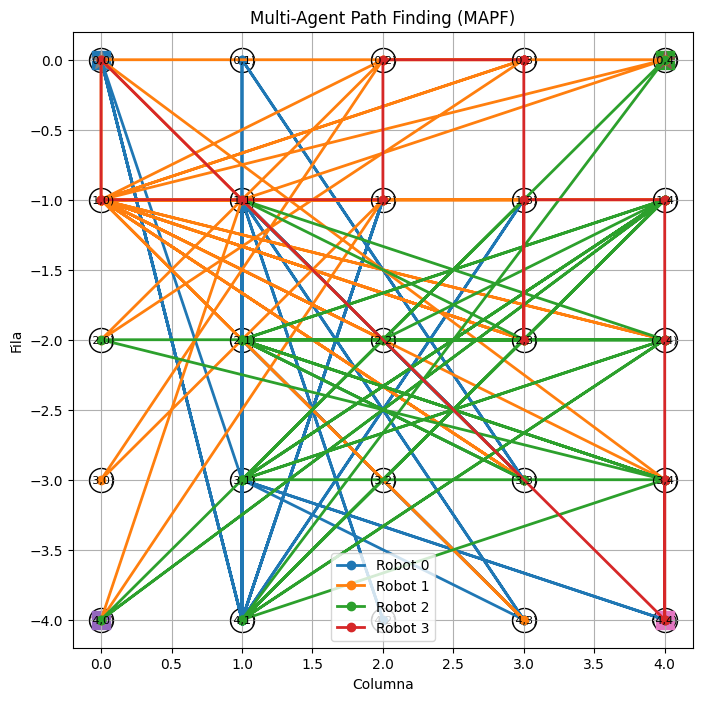

In [17]:
plt.figure(figsize=(8, 8))

# Dibujar la rejilla
for i in range(FILAS):
    for j in range(COLUMNAS):
        plt.scatter(j, -i, s=300, facecolors="white", edgecolors="black")
        plt.text(
            j,
            -i,
            f"({i},{j})",
            ha="center",
            va="center",
            fontsize=8
        )

# Dibujar las rutas
for i in R:

    posiciones = [robots[i]["start"]]

    for k, a, b in rutas[i]:
        posiciones.append(b)

    x = [p[1] for p in posiciones]
    y = [-p[0] for p in posiciones]

    plt.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=f"Robot {i}"
    )

    # Inicio
    s = robots[i]["start"]
    plt.scatter(
        s[1],
        -s[0],
        s=180,
        marker="s"
    )

    # Destino
    g = robots[i]["goal"]
    plt.scatter(
        g[1],
        -g[0],
        s=200,
        marker="*"
    )

plt.title("Multi-Agent Path Finding (MAPF)")
plt.xlabel("Columna")
plt.ylabel("Fila")
plt.grid(True)
plt.legend()
plt.show()